<a href="https://colab.research.google.com/github/pushkarapushu67-netizen/Take-it-smart-week--7-task/blob/main/week_7_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#****Machine Learning Task: House Price Prediction (Regression)****

## **Problem Statement**
The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a **Machine Learning regression model** that predicts **the price of a house** using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

Students are required to analyze the dataset, perform data preprocessing, apply feature engineering techniques, train multiple regression models, and evaluate their performance to identify the best model for predicting house prices

**Imported Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load Data**

In [ ]:
data = pd.read_csv('house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


## **Understanding Variables**
**SquareFeet** – Total area of the house measured in square feet.

**Bedrooms** – Number of bedrooms available in the house.

**Bathrooms** – Number of bathrooms in the house.

**LotSize** – Total land area of the property (including open space like garden or yard).

**GarageSize** – Number of vehicles that can be accommodated in the garage.

**NeighborhoodQuality** – Rating or quality of the locality where the house is located (higher value means better area).

**YearBuilt** – The year in which the house was constructed.

**Price** – Selling price of the house (target variable to be predicted).

**Basic Checks**

In [ ]:
data.shape

(1000, 8)

In [ ]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [ ]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
cat_cols = data.select_dtypes(include=['object'])
cat_cols

""
0
1
2
3
4
...
995
996
997
998


In [ ]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
# check for unique values
for x in cat_cols:
  print(x,'--->',data[x].unique())

In [ ]:
# check for value counts
for x in cat_cols:
  print(data[x].value_counts())

**Data Cleaning**

**Check for missing values**

In [ ]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Handling missing values**

In [ ]:
data.fillna(data.mean(), inplace=True)

**Check for duplicates**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Remove Duplicate records**

In [ ]:
data = data.drop_duplicates()

**Exploratory data analysis**

**Univariate**

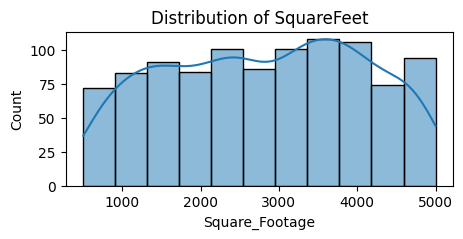

In [ ]:
# check trhe distribution of squarefootage
plt.figure(figsize=(5,2))
sns.histplot(data['Square_Footage'], kde=True)
plt.title("Distribution of SquareFeet")
plt.show()

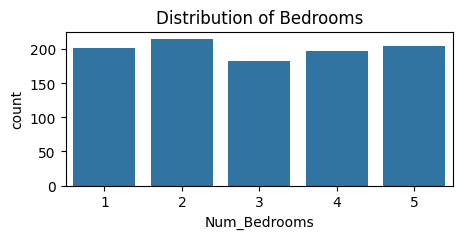

In [ ]:
# check trhe distribution of Bedroom
plt.figure(figsize=(5,2))
sns.countplot(x=data['Num_Bedrooms'])
plt.title("Distribution of Bedrooms")
plt.show()

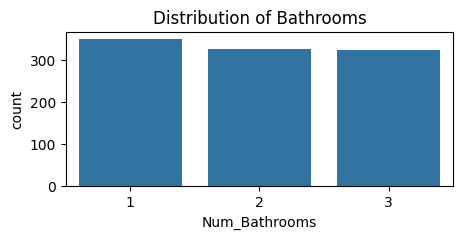

In [ ]:
# check trhe distribution of Bathroom
plt.figure(figsize=(5,2))
sns.countplot(x=data['Num_Bathrooms'])
plt.title("Distribution of Bathrooms")
plt.show()

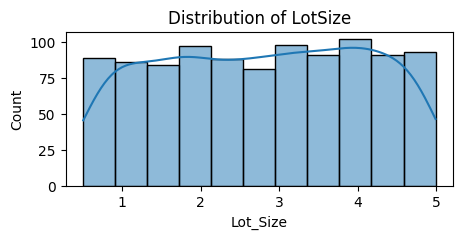

In [ ]:
# check trhe distribution of LotSize
plt.figure(figsize=(5,2))
sns.histplot(data['Lot_Size'], kde=True)
plt.title("Distribution of LotSize")
plt.show()


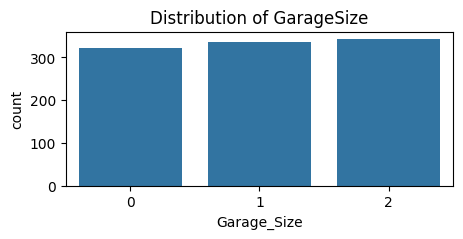

In [ ]:
# check trhe distribution of Garage Size
plt.figure(figsize=(5,2))
sns.countplot(x=data['Garage_Size'])
plt.title("Distribution of GarageSize")
plt.show()

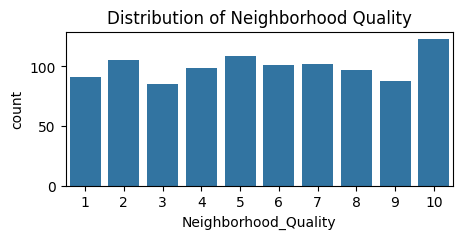

In [ ]:
# check trhe distribution of Neighbourhood Quality
plt.figure(figsize=(5,2))
sns.countplot(x=data['Neighborhood_Quality'])
plt.title("Distribution of Neighborhood Quality")
plt.show()

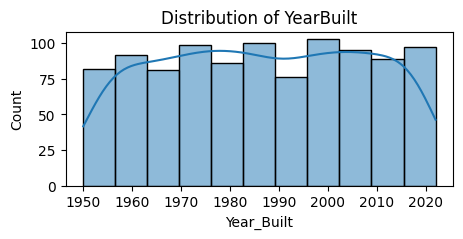

In [ ]:
# check trhe distribution of Year Built
plt.figure(figsize=(5,2))
sns.histplot(data['Year_Built'], kde=True)
plt.title("Distribution of YearBuilt")
plt.show()

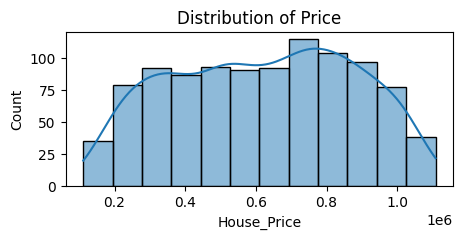

In [ ]:
# check trhe distribution of House Pirce
plt.figure(figsize=(5,2))
sns.histplot(data['House_Price'], kde=True)
plt.title("Distribution of Price")
plt.show()

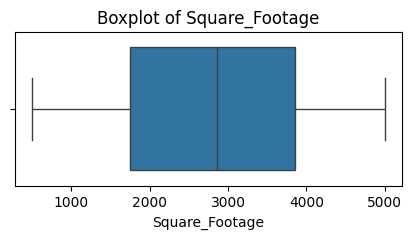

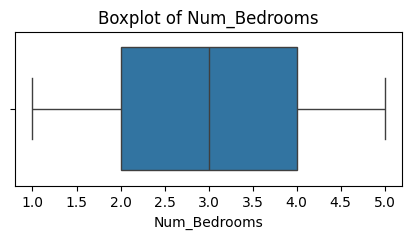

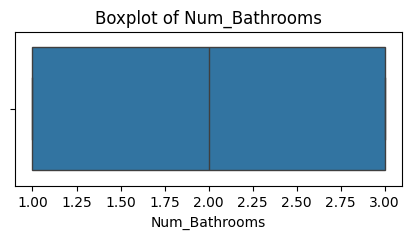

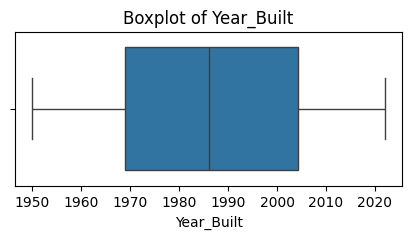

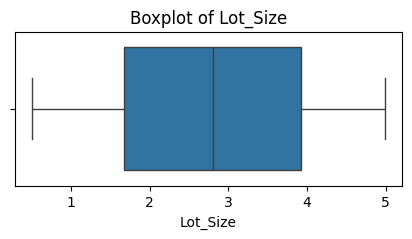

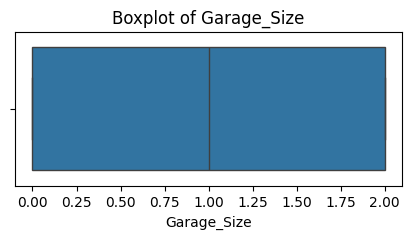

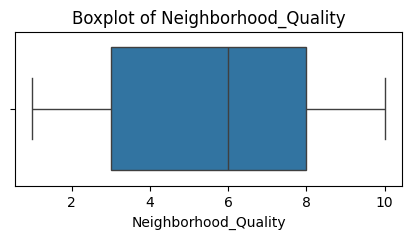

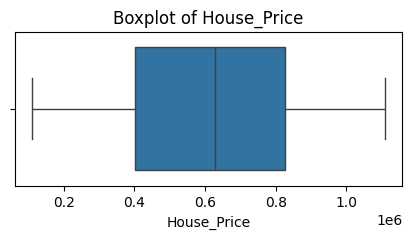

In [ ]:
for col in data.columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Bivariate Analysis**

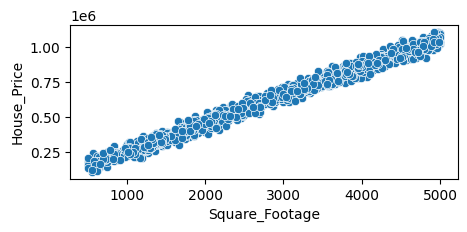

In [ ]:
# SquareFeet v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Square_Footage', y='House_Price')
plt.show()

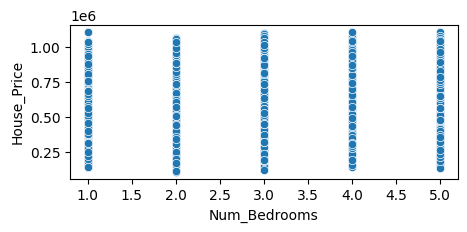

In [ ]:
# Bedrooms v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Num_Bedrooms', y='House_Price')
plt.show()

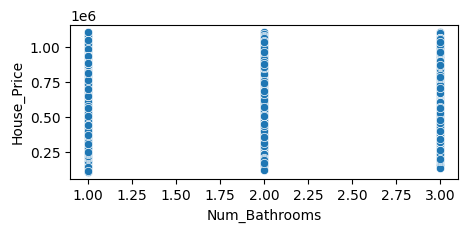

In [ ]:
# Bathrooms v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Num_Bathrooms', y='House_Price')
plt.show()

In [ ]:
# LotSize v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Square_Footage', y='House_Price')
plt.show()

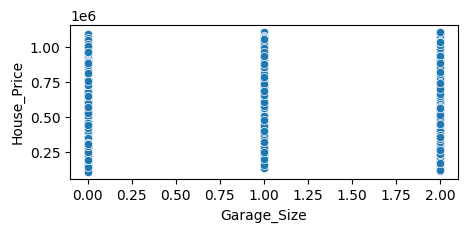

In [ ]:
# GarageSize v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Garage_Size', y='House_Price')
plt.show()

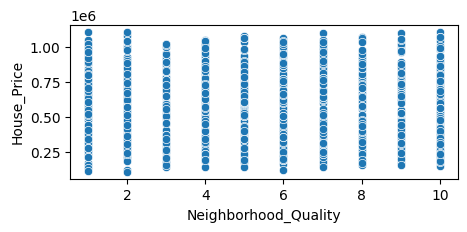

In [ ]:
# NeighborhoodQuality v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Neighborhood_Quality', y='House_Price')
plt.show()

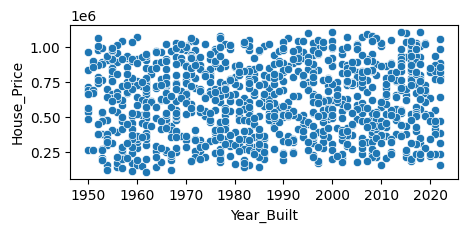

In [ ]:
# YearBuilt v/s Price
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Year_Built', y='House_Price')
plt.show()

In [ ]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Pair Plot**

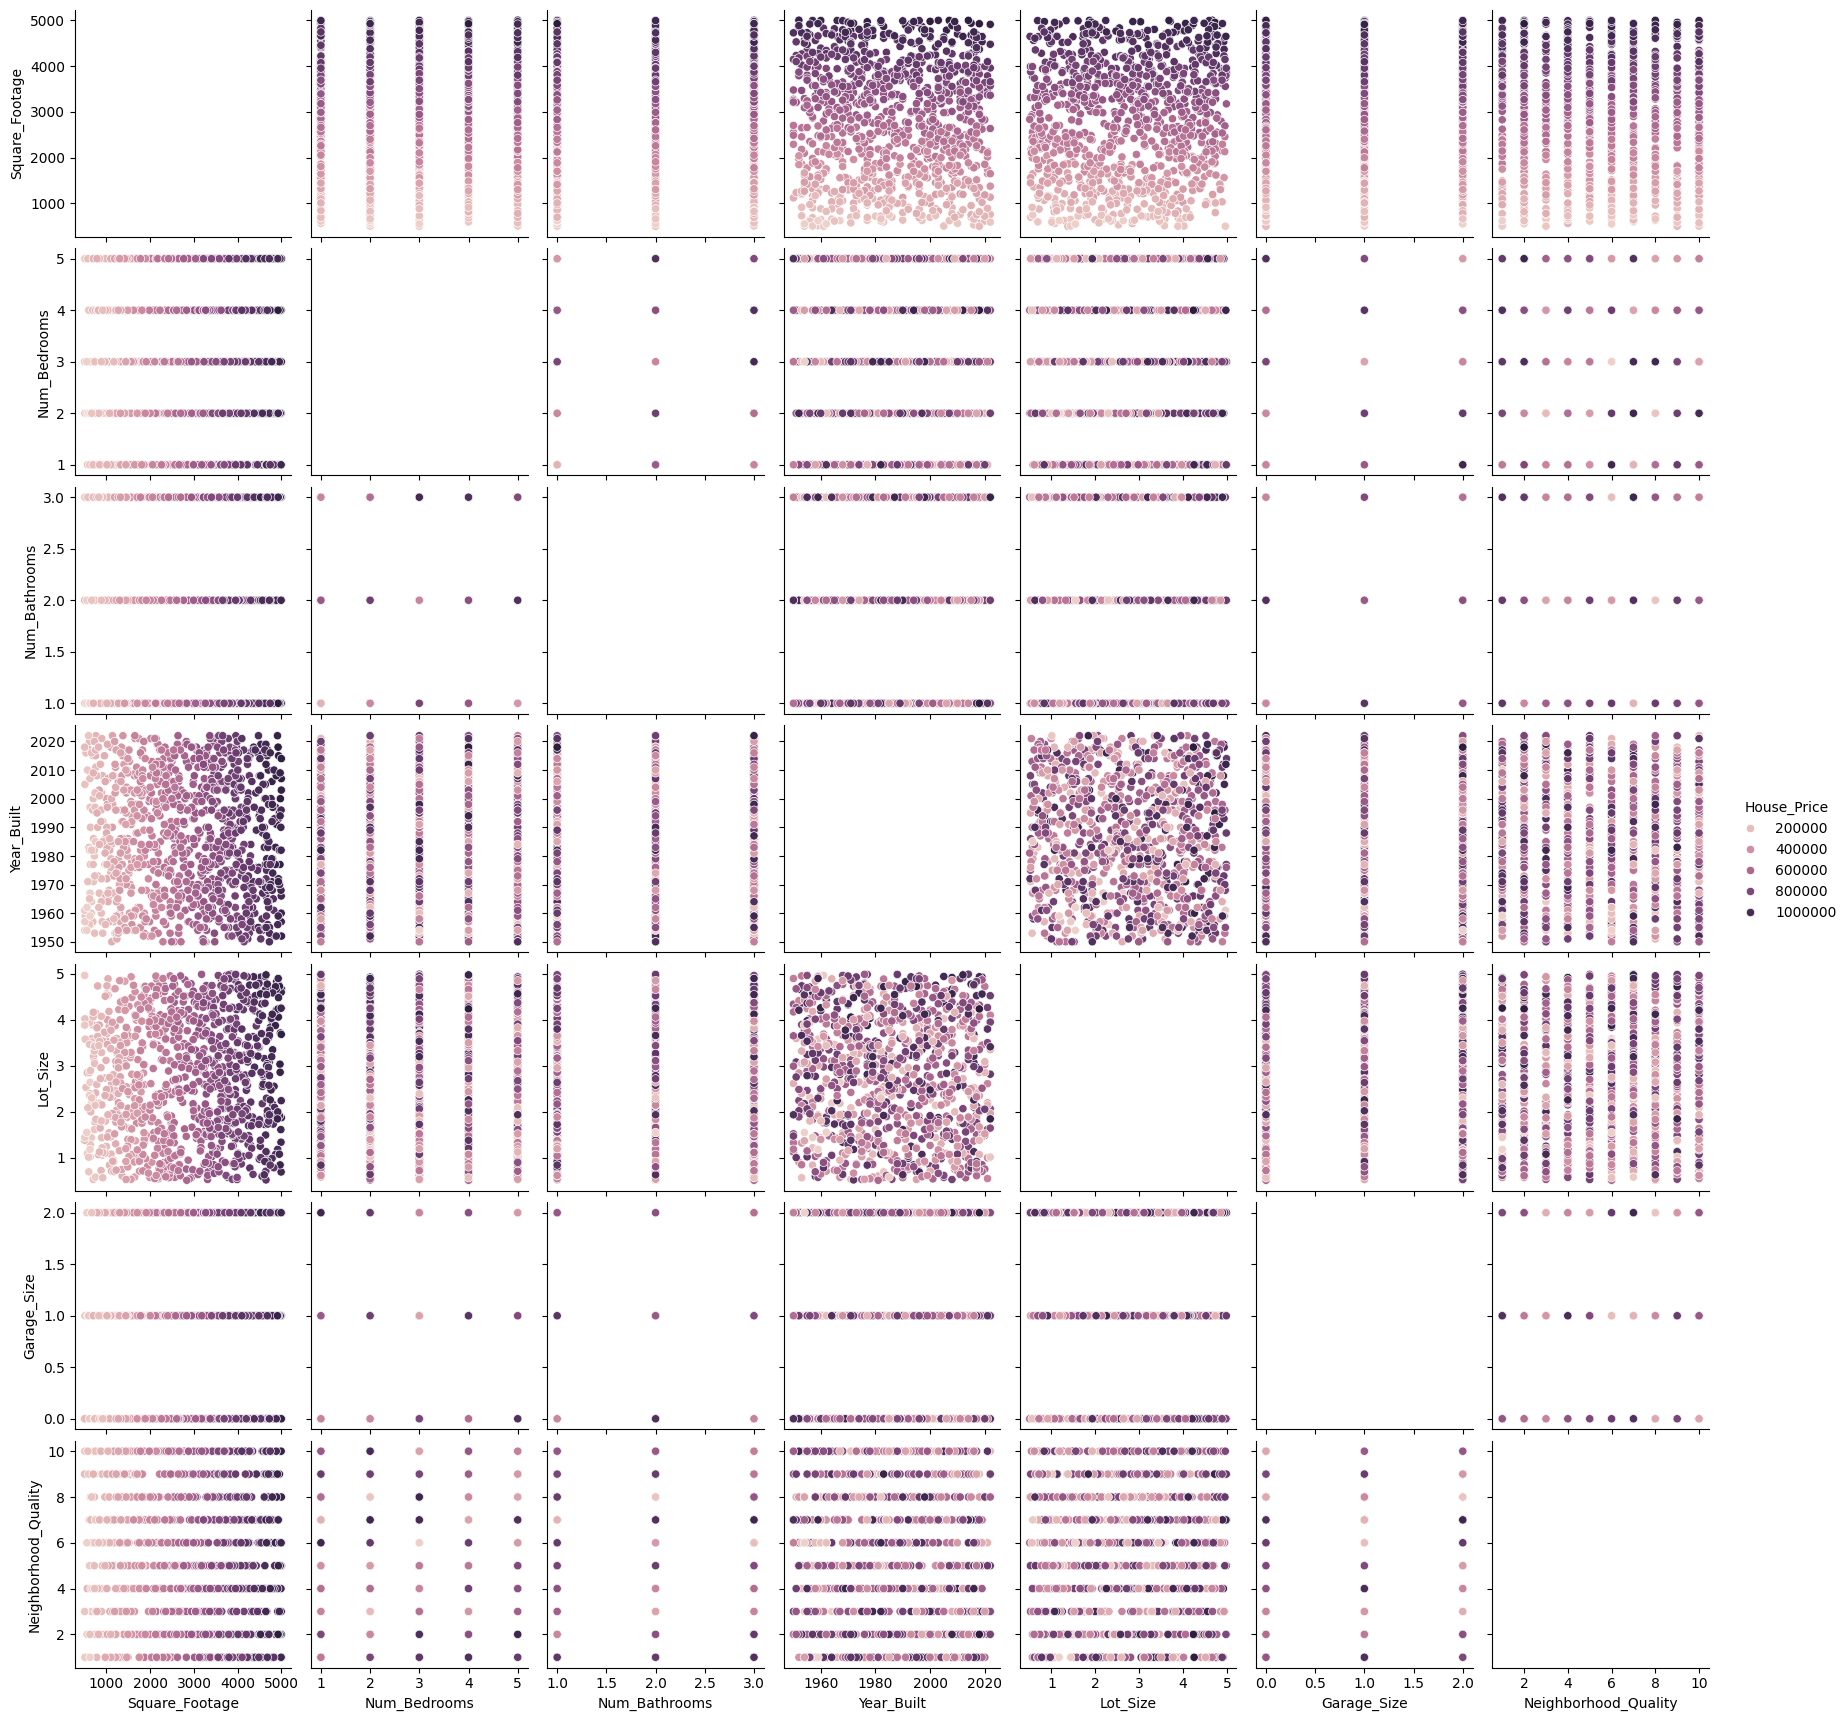

In [ ]:
sns.pairplot(data,hue='House_Price')

**Correlation Heatmap**

In [ ]:
# finding corr
num_cols.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


<Axes: >

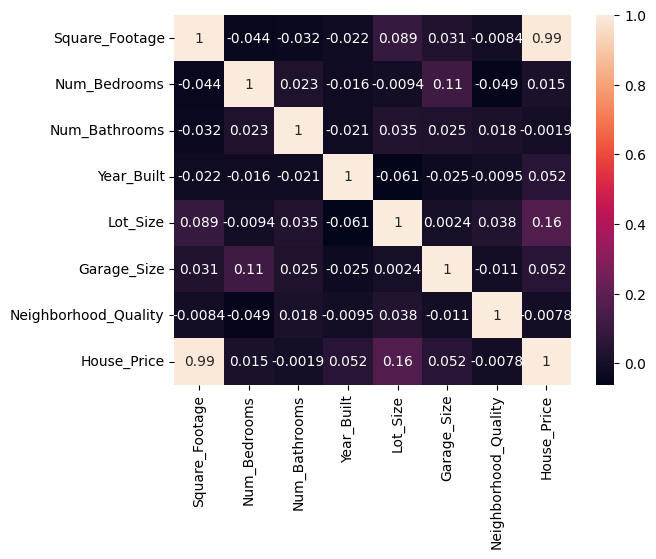

In [ ]:
sns.heatmap(num_cols.corr(),annot=True)

**Handle Outliers**

**detect**

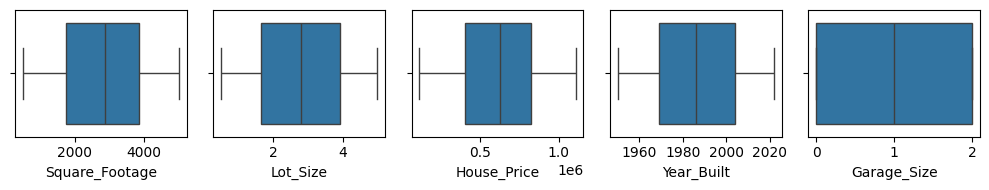

In [ ]:
# Square_Footage, Lot_Size, House_Price, Year_Built, Garage_Size

fig, ax = plt.subplots(1,5, figsize=(10,2))

sns.boxplot(data=data, x='Square_Footage', ax=ax[0])
sns.boxplot(data=data, x='Lot_Size', ax=ax[1])
sns.boxplot(data=data, x='House_Price', ax=ax[2])
sns.boxplot(data=data, x='Year_Built', ax=ax[3])
sns.boxplot(data=data, x='Garage_Size', ax=ax[4])

plt.tight_layout()

In [ ]:
# Square_Footage, Lot_Size, House_Price, Year_Built  check distribution

fig, ax = plt.subplots(1,4, figsize=(10,2))

sns.histplot(data=data, x='Square_Footage', ax=ax[0])
sns.histplot(data=data, x='Lot_Size', ax=ax[1])
sns.histplot(data=data, x='House_Price', ax=ax[2])
sns.histplot(data=data, x='Year_Built', ax=ax[3])

plt.tight_layout()

In [ ]:
#check skewness
cols = ['Square_Footage','Lot_Size','House_Price','Year_Built']

for x in cols:
    print(x, '-->', data[x].skew())
    print()

Square_Footage --> -0.06600064579808387

Lot_Size --> -0.044288075933306616

House_Price --> -0.06395513907654668

Year_Built --> -0.021253592163707695



**Square_Footage**

In [ ]:
# check skewness
skew = data['Square_Footage'].skew()
print("Skewness:", skew)

# choose multiplier
if abs(skew) < 1:
    k = 1.5
elif abs(skew) < 2:
    k = 2
else:
    k = 3

Q1 = data['Square_Footage'].quantile(0.25)
Q3 = data['Square_Footage'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - k * IQR
upper_limit = Q3 + k * IQR

outliers_sqft = data[(data['Square_Footage'] > upper_limit) | (data['Square_Footage'] < lower_limit)]
print("Square_Footage Outliers:")
display(outliers_sqft)

print("Percentage:", len(outliers_sqft)/len(data)*100)

data = data[(data['Square_Footage'] >= lower_limit) & (data['Square_Footage'] <= upper_limit)]

Skewness: -0.06600064579808387
Square_Footage Outliers:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price


Percentage: 0.0


**Lot_Size**

In [ ]:
skew = data['Lot_Size'].skew()
print("Skewness:", skew)

if abs(skew) < 1:
    k = 1.5
elif abs(skew) < 2:
    k = 2
else:
    k = 3

Q1 = data['Lot_Size'].quantile(0.25)
Q3 = data['Lot_Size'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - k * IQR
upper_limit = Q3 + k * IQR

outliers_lot = data[(data['Lot_Size'] > upper_limit) | (data['Lot_Size'] < lower_limit)]
print("Lot_Size Outliers:")
display(outliers_lot)

print("Percentage:", len(outliers_lot)/len(data)*100)

data = data[(data['Lot_Size'] >= lower_limit) & (data['Lot_Size'] <= upper_limit)]

Skewness: -0.044288075933306616
Lot_Size Outliers:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price


Percentage: 0.0


**House_Price**

In [ ]:
skew = data['House_Price'].skew()
print("Skewness:", skew)

if abs(skew) < 1:
    k = 1.5
elif abs(skew) < 2:
    k = 2
else:
    k = 3   # usually applies here

Q1 = data['House_Price'].quantile(0.25)
Q3 = data['House_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - k * IQR
upper_limit = Q3 + k * IQR

outliers_price = data[(data['House_Price'] > upper_limit) | (data['House_Price'] < lower_limit)]
print("House_Price Outliers:")
display(outliers_price)

print("Percentage:", len(outliers_price)/len(data)*100)

data = data[(data['House_Price'] >= lower_limit) & (data['House_Price'] <= upper_limit)]

Skewness: -0.06395513907654668
House_Price Outliers:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price


Percentage: 0.0


**Year_Built**

In [ ]:
skew = data['Year_Built'].skew()
print("Skewness:", skew)

if abs(skew) < 1:
    k = 1.5
elif abs(skew) < 2:
    k = 2
else:
    k = 3

Q1 = data['Year_Built'].quantile(0.25)
Q3 = data['Year_Built'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - k * IQR
upper_limit = Q3 + k * IQR

outliers_year = data[(data['Year_Built'] > upper_limit) | (data['Year_Built'] < lower_limit)]
print("Year_Built Outliers:")
display(outliers_year)

print("Percentage:", len(outliers_year)/len(data)*100)

data = data[(data['Year_Built'] >= lower_limit) & (data['Year_Built'] <= upper_limit)]

Skewness: -0.021253592163707695
Year_Built Outliers:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price


Percentage: 0.0


In [ ]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

#****Encoding****

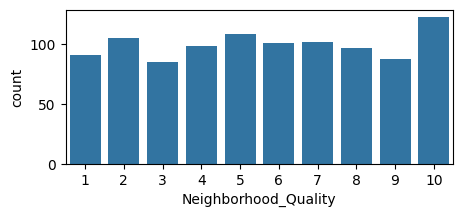

In [ ]:
# NeighborhoodQuality
plt.figure(figsize=(5,2))
sns.countplot(data=data, x='Neighborhood_Quality')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data.loc[:,'Neighborhood_Quality'] = encoder.fit_transform(data.loc[:,'Neighborhood_Quality'])

In [ ]:
data[['Neighborhood_Quality']].head()

,Neighborhood_Quality
0,4
1,5
2,8
3,7
4,7


**Garage_Size**

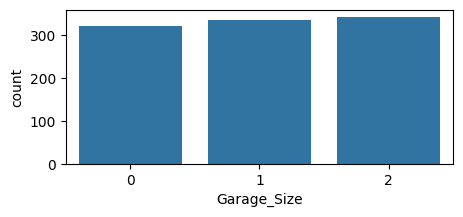

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data=data, x='Garage_Size')
plt.show()

In [ ]:
data.loc[:,'Garage_Size_Encoded'] = data.loc[:,'Garage_Size'].map({
    'Small':0,
    'Medium':1,
    'Large':2
})

**Log Transformation**

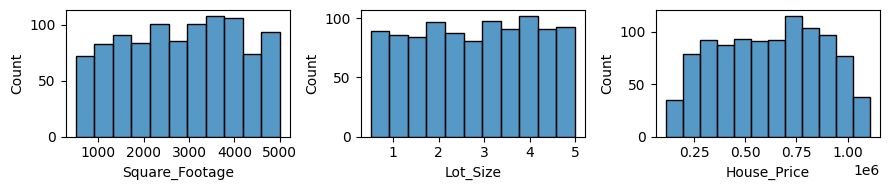

In [ ]:
# Square_Footage, Lot_Size, House_Price

fig, ax = plt.subplots(1,3, figsize=(9,2))

sns.histplot(data=data, x='Square_Footage', ax=ax[0])
sns.histplot(data=data, x='Lot_Size', ax=ax[1])
sns.histplot(data=data, x='House_Price', ax=ax[2])

plt.tight_layout()

In [ ]:
#check for skewness
cols = ['Square_Footage','Lot_Size','House_Price']

for x in cols:
    print(x, '-->', data[x].skew())
    print()

Square_Footage --> -0.06600064579808387

Lot_Size --> -0.044288075933306616

House_Price --> -0.06395513907654668



In [ ]:
data.loc[:,'Square_Footage_Log'] = np.log1p(data.loc[:,'Square_Footage'])

In [ ]:
data.loc[:,'Lot_Size_Log'] = np.log1p(data.loc[:,'Lot_Size'])

In [ ]:
data.loc[:,'House_Price_Log'] = np.log1p(data.loc[:,'House_Price'])

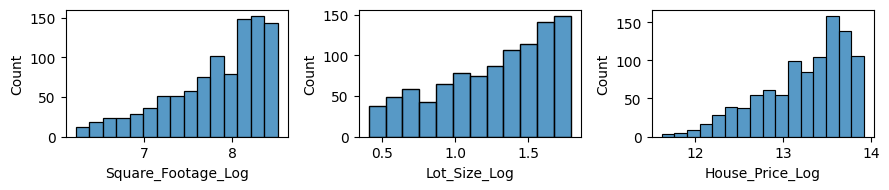

In [ ]:
#after transformation
# Square_Footage_Log, Lot_Size_Log, House_Price_Log

fig, ax = plt.subplots(1,3, figsize=(9,2))

sns.histplot(data=data, x='Square_Footage_Log', ax=ax[0])
sns.histplot(data=data, x='Lot_Size_Log', ax=ax[1])
sns.histplot(data=data, x='House_Price_Log', ax=ax[2])

plt.tight_layout()

In [ ]:
#skewness
cols = ['Square_Footage_Log','Lot_Size_Log','House_Price_Log']

for x in cols:
    print(x, '-->', data[x].skew())
    print()

Square_Footage_Log --> -0.8710067440704501

Lot_Size_Log --> -0.518351637720857

House_Price_Log --> -0.8014642343477415



#****Separate Features and Target Variable****

In [ ]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price',
       'Garage_Size_Encoded', 'Square_Footage_Log', 'Lot_Size_Log',
       'House_Price_Log'],
      dtype='object')

**Separate Features (X) and Target (y)**

In [ ]:
X = data.drop('House_Price', axis=1)
y = data['House_Price']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 11)
y shape: (1000,)


In [ ]:
print("Features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Features (X):


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
0,7.215975,2,1,1981,0.469777,0,4,NaN,7.215975,0.469777,12.477564
1,8.360071,3,3,2016,1.749724,1,5,NaN,8.360071,1.749724,13.800663
2,8.186743,1,2,2016,1.533598,0,8,NaN,8.186743,1.533598,13.564454
3,6.874198,1,2,1977,1.316587,1,7,NaN,6.874198,1.316587,12.344529
4,8.502486,2,1,1993,1.740303,0,7,NaN,8.502486,1.740303,13.856405


Target (y):


,House_Price
0,12.477564
1,13.800663
2,13.564454
3,12.344529
4,13.856405


**Split data for training and testing**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 11)
X_test shape: (200, 11)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
print("X_train:")
display(X_train.head())

print("X_test:")
display(X_test.head())

print("y_train:")
display(y_train.head())

print("y_test:")
display(y_test.head())

X_train:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
29,7.615298,2,3,1967,1.024172,2,1,NaN,7.615298,1.024172,12.981184
535,8.166216,5,3,1966,1.611425,0,9,NaN,8.166216,1.611425,13.577616
695,8.413609,2,3,2014,1.633611,0,6,NaN,8.413609,1.633611,13.800905
557,8.123261,4,2,2000,0.947913,0,0,NaN,8.123261,0.947913,13.509380
836,7.962764,5,1,1974,1.487703,2,5,NaN,7.962764,1.487703,13.363824


X_test:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
521,8.297294,3,1,2016,1.130787,1,4,NaN,8.297294,1.130787,13.711262
737,7.745436,3,1,1988,0.862731,1,3,NaN,7.745436,0.862731,13.111380
740,8.457231,1,3,1962,1.027106,1,7,NaN,8.457231,1.027106,13.763591
660,8.503703,2,1,1972,1.701032,1,1,NaN,8.503703,1.701032,13.855106
411,8.201660,1,1,1994,1.605628,0,8,NaN,8.201660,1.605628,13.584853


y_train:


,House_Price
29,12.981184
535,13.577616
695,13.800905
557,13.509380
836,13.363824


y_test:


,House_Price
521,13.711262
737,13.111380
740,13.763591
660,13.855106
411,13.584853


**Feature scaling**

In [ ]:
#Before Scaling
X_train.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
29,7.615298,2,3,1967,1.024172,2,1,NaN,7.615298,1.024172,12.981184
535,8.166216,5,3,1966,1.611425,0,9,NaN,8.166216,1.611425,13.577616
695,8.413609,2,3,2014,1.633611,0,6,NaN,8.413609,1.633611,13.800905
557,8.123261,4,2,2000,0.947913,0,0,NaN,8.123261,0.947913,13.509380
836,7.962764,5,1,1974,1.487703,2,5,NaN,7.962764,1.487703,13.363824


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform test data
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
#Scaled Data
print("Scaled X_train:")
display(X_train_scaled.head())

print("Scaled X_test:")
display(X_test_scaled.head())

Scaled X_train:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
0,-0.356232,-0.681986,1.261133,-0.957011,-0.629046,1.201331,-1.234358,NaN,-0.356232,-0.629046,-0.505556
1,0.637380,1.429971,1.261133,-1.005096,0.926253,-1.237920,1.511520,NaN,0.637380,0.926253,0.706666
2,1.083567,-0.681986,1.261133,1.302982,0.985009,-1.237920,0.481816,NaN,1.083567,0.985009,1.160491
3,0.559908,0.725985,0.035244,0.629793,-0.831014,-1.237920,-1.577593,NaN,0.559908,-0.831014,0.567979
4,0.270442,1.429971,-1.190644,-0.620416,0.598582,1.201331,0.138581,NaN,0.270442,0.598582,0.272143


Scaled X_test:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Garage_Size_Encoded,Square_Footage_Log,Lot_Size_Log,House_Price_Log
0,0.873787,0.022000,-1.190644,1.399152,-0.346686,-0.018294,-0.204654,NaN,0.873787,-0.346686,0.978297
1,-0.121522,0.022000,-1.190644,0.052773,-1.056613,-0.018294,-0.547889,NaN,-0.121522,-1.056613,-0.240938
2,1.162241,-1.385972,1.261133,-1.197436,-0.621277,-0.018294,0.825051,NaN,1.162241,-0.621277,1.084653
3,1.246056,-0.681986,-1.190644,-0.716586,1.163569,-0.018294,-1.234358,NaN,1.246056,1.163569,1.270654
4,0.701305,-1.385972,-1.190644,0.341283,0.910899,-1.237920,1.168285,NaN,0.701305,0.910899,0.721375


# Logistic Regression

In [ ]:
print("Total NaN in X_train:", X_train.isnull().sum().sum())
print("Total NaN in X_test:", X_test.isnull().sum().sum())

Total NaN in X_train: 800
Total NaN in X_test: 200


In [ ]:
# remove columns with all NaN
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test[X_train.columns]   # keep same columns

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# convert back safely
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

In [ ]:
y_test = y_test.reset_index(drop=True)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler # Re-import StandardScaler for clarity within the cell
import pandas as pd # Import pandas if not already globally available for DataFrame conversion

# model
lr_model = LinearRegression()

# Re-initialize and re-apply StandardScaler to the (now clean) X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# train
lr_model.fit(X_train_scaled, y_train)

# predict
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
lr_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted_LR': y_pred_lr
})

print("Linear Regression Predictions:")
display(lr_results.head())

Linear Regression Predictions:


,Actual,Predicted_LR
0,13.711262,13.711262
1,13.111380,13.111380
2,13.763591,13.763591
3,13.855106,13.855106
4,13.584853,13.584853


**KNN Training model**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
knn_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted_KNN': y_pred_knn
})
print("KNN Predictions:")
display(knn_results.head())

KNN Predictions:


,Actual,Predicted_KNN
0,13.711262,13.576552
1,13.111380,13.071524
2,13.763591,13.586860
3,13.855106,13.721028
4,13.584853,13.547117


**comparision**

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Linear_Regression': y_pred_lr,
    'KNN': y_pred_knn
})

print("Model Comparison:")
display(comparison.head())

Model Comparison:


,Actual,Linear_Regression,KNN
0,13.711262,13.711262,13.576552
1,13.111380,13.111380,13.071524
2,13.763591,13.763591,13.586860
3,13.855106,13.855106,13.721028
4,13.584853,13.584853,13.547117


# **Evaluate the model**

In [ ]:
def evaluate_model(y_test, y_pred, X_test):

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    p = X_test.shape[1]

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return mae, mse, rmse, mape, r2, adj_r2

**Evaluate linear regression**

In [ ]:
lr_metrics = evaluate_model(y_test, y_pred_lr, X_test_scaled)

print("Linear Regression Metrics:")
print("MAE:", lr_metrics[0])
print("MSE:", lr_metrics[1])
print("RMSE:", lr_metrics[2])
print("MAPE:", lr_metrics[3])
print("R2 Score:", lr_metrics[4])
print("Adjusted R2:", lr_metrics[5])

Linear Regression Metrics:
MAE: 0.0
MSE: 0.0
RMSE: 0.0
MAPE: 0.0
R2 Score: 1.0
Adjusted R2: 1.0


**Evaluate KNN**

In [ ]:
knn_metrics = evaluate_model(y_test, y_pred_knn, X_test_scaled)

print("\nKNN Metrics:")
print("MAE:", knn_metrics[0])
print("MSE:", knn_metrics[1])
print("RMSE:", knn_metrics[2])
print("MAPE:", knn_metrics[3])
print("R2 Score:", knn_metrics[4])
print("Adjusted R2:", knn_metrics[5])


KNN Metrics:
MAE: 0.08698372306281633
MSE: 0.011285567695263503
RMSE: 0.10623355258704052
MAPE: 0.6593889904746562
R2 Score: 0.9530601803777077
Adjusted R2: 0.9505765920379039


In [ ]:
results = pd.DataFrame({
    'Metric': ['MAE','MSE','RMSE','MAPE','R2','Adjusted R2'],
    'Linear Regression': lr_metrics,
    'KNN': knn_metrics
})

display(results)

,Metric,Linear Regression,KNN
0,MAE,0.0,0.086984
1,MSE,0.0,0.011286
2,RMSE,0.0,0.106234
3,MAPE,0.0,0.659389
4,R2,1.0,0.953060
5,Adjusted R2,1.0,0.950577
